<a href="https://colab.research.google.com/github/samer-glitch/TADP-Trustworthy-Data-Preparation-via-Federated-Governance-and-Tamper-Evident-Provenance/blob/main/Energy-Cost-CO2%20ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

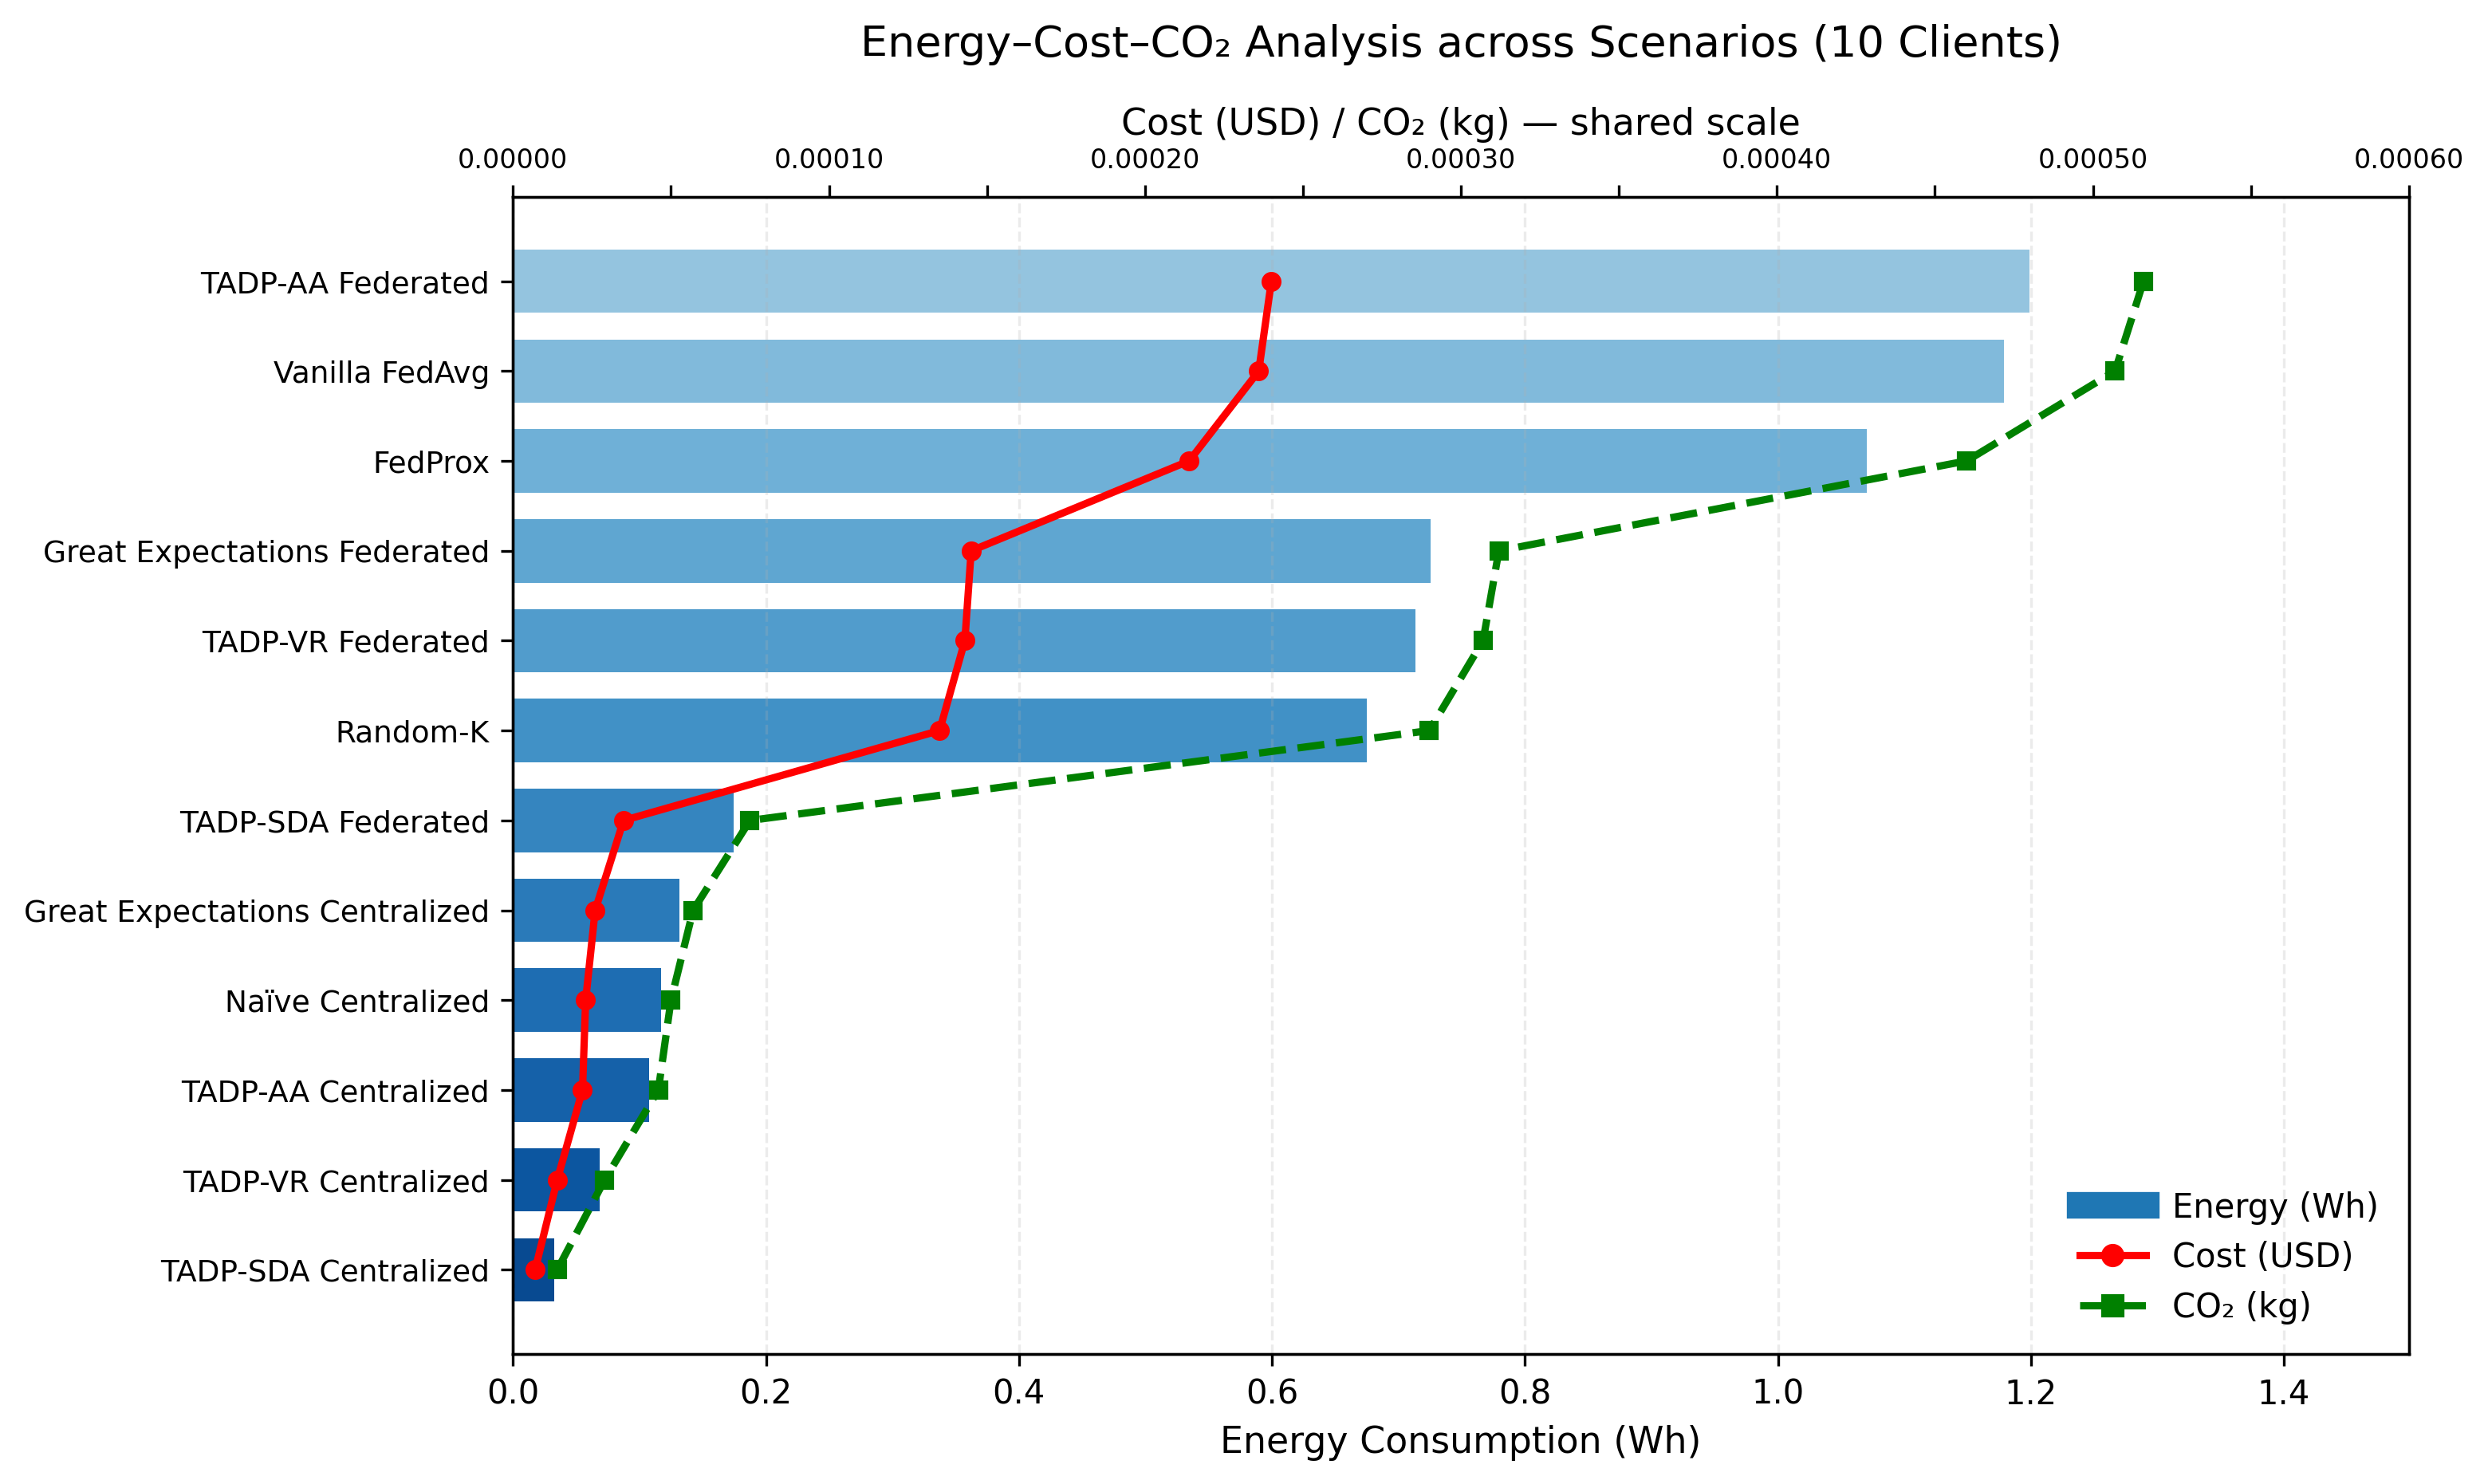

'/mnt/data/energy_cost_co2_k10_LINEAR_SHARED_TOP_TIGHT.png'

In [22]:
# Generate and DISPLAY the figure inline, and also save a 300‑dpi PNG.
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.lines import Line2D
import math

def round_up(x, step):
    return math.ceil(x / step) * step

# ---- TRUE DATA (K=10) ----
data = [
    ["TADP-AA Federated", 1.199109, 0.000240, 0.000516],
    ["Great Expectations Federated", 0.725296, 0.000145, 0.000312],
    ["FedProx", 1.070076, 0.000214, 0.000460],
    ["Vanilla FedAvg", 1.178454, 0.000236, 0.000507],
    ["Random-K", 0.675060, 0.000135, 0.000290],
    ["TADP-VR Federated", 0.713697, 0.000143, 0.000307],
    ["TADP-SDA Federated", 0.174535, 0.000035, 0.000075],
    ["Naïve Centralized", 0.117019, 0.000023, 0.000050],
    ["Great Expectations Centralized", 0.131645, 0.000026, 0.000057],
    ["TADP-AA Centralized", 0.107561, 0.000022, 0.000046],
    ["TADP-VR Centralized", 0.068598, 0.000014, 0.000029],
    ["TADP-SDA Centralized", 0.032901, 0.000007, 0.000014],
]
df = pd.DataFrame(data, columns=["Scenario", "Energy_Wh", "Cost_USD", "CO2_kg"])
df = df.sort_values("Energy_Wh", ascending=False).reset_index(drop=True)

# Y spacing
bar_height = 0.6
bar_gap = 0.25
y_positions = np.arange(len(df)) * (bar_height + bar_gap)

# Figure
fig_height = max(6.5, len(df) * 0.45)
fig, ax_energy = plt.subplots(figsize=(10.5, fig_height), dpi=300)

# Energy bars
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(df)))
ax_energy.barh(y_positions, df["Energy_Wh"], color=colors, height=bar_height, edgecolor="none")
ax_energy.set_yticks(y_positions)
ax_energy.set_yticklabels(df["Scenario"], fontsize=9)
ax_energy.invert_yaxis()
ax_energy.set_xlabel("Energy Consumption (Wh)", fontsize=11)
ax_energy.set_xlim(0, 1.25 * df["Energy_Wh"].max())
ax_energy.grid(alpha=0.25, linestyle="--", axis="x")

# Top axis — dynamic, tight scale
max_top = df[["Cost_USD", "CO2_kg"]].max().max()
xmax = round_up(max_top * 1.08, 5e-5)  # round to nearest 0.00005 above
ax_top = ax_energy.twiny()
ax_top.set_xlim(0, xmax)
ax_top.set_xlabel("Cost (USD) / CO₂ (kg) — shared scale", fontsize=11)
ax_top.tick_params(axis="x", labelsize=8)

# Build nice ticks every 0.00005; reduce clutter by skipping
step = 5e-5
ticks = np.arange(0, xmax + step/2, step)
ax_top.set_xticks(ticks)
labels = [f"{t:0.5f}" if (i % 2 == 0) else "" for i, t in enumerate(ticks)]
ax_top.set_xticklabels(labels)

# Lines
ax_top.plot(df["Cost_USD"], y_positions, "o-", color="red", linewidth=2.2, markersize=5, label="Cost (USD)")
ax_top.plot(df["CO2_kg"], y_positions, "s--", color="green", linewidth=2.2, markersize=5, label="CO₂ (kg)")

# Legend
handles = [
    Line2D([0], [0], color="#1f77b4", lw=8, label="Energy (Wh)"),
    Line2D([0], [0], color="red", lw=2.2, marker="o", label="Cost (USD)"),
    Line2D([0], [0], color="green", lw=2.2, ls="--", marker="s", label="CO₂ (kg)"),
]
ax_energy.legend(handles=handles, loc="lower right", frameon=False)

plt.title("Energy–Cost–CO₂ Analysis across Scenarios (10 Clients)", fontsize=13, pad=15)
plt.tight_layout(rect=[0, 0.01, 1, 0.98])

# Save + Show
out_path = "/mnt/data/energy_cost_co2_k10_LINEAR_SHARED_TOP_TIGHT.png"
os.makedirs(os.path.dirname(out_path), exist_ok=True)
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

out_path
